In [1]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns

In [2]:
d1 = pd.read_csv('C:/Users/hp/Documents/Airbnb Project/Airbnb Data/Listings.csv', encoding='latin-1')



C:\Users\hp\AppData\Local\Temp\ipykernel_5100\2915026510.py:1: DtypeWarning: Columns (5,13) have mixed types. Specify dtype option on import or set low_memory=False.
  d1 = pd.read_csv('C:/Users/hp/Documents/Airbnb Project/Airbnb Data/Listings.csv', encoding='latin-1')


# Data Familiarization

In [3]:
d1.head(2)

,listing_id,name,host_id,host_since,host_location,host_response_time,host_response_rate,host_acceptance_rate,host_is_superhost,host_total_listings_count,...,minimum_nights,maximum_nights,review_scores_rating,review_scores_accuracy,review_scores_cleanliness,review_scores_checkin,review_scores_communication,review_scores_location,review_scores_value,instant_bookable
0,281420,"Beautiful Flat in le Village Montmartre, Paris",1466919,2011-12-03,"Paris, Ile-de-France, France",NaN,NaN,NaN,f,1.0,...,2,1125,100.0,10.0,10.0,10.0,10.0,10.0,10.0,f
1,3705183,39 mÃÂ² Paris (Sacre CÃ âur),10328771,2013-11-29,"Paris, Ile-de-France, France",NaN,NaN,NaN,f,1.0,...,2,1125,100.0,10.0,10.0,10.0,10.0,10.0,10.0,f


In [4]:
d1.columns

Index(['listing_id', 'name', 'host_id', 'host_since', 'host_location',
       'host_response_time', 'host_response_rate', 'host_acceptance_rate',
       'host_is_superhost', 'host_total_listings_count',
       'host_has_profile_pic', 'host_identity_verified', 'neighbourhood',
       'district', 'city', 'latitude', 'longitude', 'property_type',
       'room_type', 'accommodates', 'bedrooms', 'amenities', 'price',
       'minimum_nights', 'maximum_nights', 'review_scores_rating',
       'review_scores_accuracy', 'review_scores_cleanliness',
       'review_scores_checkin', 'review_scores_communication',
       'review_scores_location', 'review_scores_value', 'instant_bookable'],
      dtype='object')

In [5]:
d1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 279712 entries, 0 to 279711
Data columns (total 33 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   listing_id                   279712 non-null  int64  
 1   name                         279537 non-null  object 
 2   host_id                      279712 non-null  int64  
 3   host_since                   279547 non-null  object 
 4   host_location                278872 non-null  object 
 5   host_response_time           150930 non-null  object 
 6   host_response_rate           150930 non-null  float64
 7   host_acceptance_rate         166625 non-null  float64
 8   host_is_superhost            279547 non-null  object 
 9   host_total_listings_count    279547 non-null  float64
 10  host_has_profile_pic         279547 non-null  object 
 11  host_identity_verified       279547 non-null  object 
 12  neighbourhood                279712 non-null  object 
 13 

In [6]:
d1.shape[0], d1.shape[1] 

(279712, 33)

### fixing price before eda

In [7]:
d1['city'].unique()

array(['Paris', 'New York', 'Bangkok', 'Rio de Janeiro', 'Sydney',
       'Istanbul', 'Rome', 'Hong Kong', 'Mexico City', 'Cape Town'],
      dtype=object)

In [ ]:
city_to_country = {
    'Paris': 'France',
    'New York': 'United States',
    'Bangkok': 'Thailand',
    'Rio de Janeiro': 'Brazil',
    'Sydney': 'Australia',
    'Istanbul': 'Türkiye',
    'Rome': 'Italy',
    'Hong Kong': 'Hong Kong',
    'Mexico City': 'Mexico',
    'Cape Town': 'South Africa'
}

rates = {
    'France': 0.8425,
    'United States': 1.0,
    'Thailand': 31.0821,
    'Brazil': 5.2131,
    'Australia': 1.4108,
    'Türkiye': 43.733,
    'Italy': 0.8425,
    'Hong Kong': 7.8166,
    'Mexico': 17.2223,
    'South Africa': 15.9681
}

d1['country_clean'] = d1['city'].map(city_to_country)
d1['usd_rate'] = d1['country_clean'].map(rates)
d1['price_usd'] = d1['price'] / d1['usd_rate']



extracted country from the city as it is the listing city, reliable, cleaner and logical choice than host location as currency conversion must depend on listing location, not host location,


# EDA


In [9]:
nume = d1.select_dtypes(include =['float64', 'int64'])
cate = d1.select_dtypes(include =['object'])

In [10]:
nume.columns.shape[0], cate.columns.shape[0]

(21, 15)

In [11]:
nume.columns, cate.columns

(Index(['listing_id', 'host_id', 'host_response_rate', 'host_acceptance_rate',
        'host_total_listings_count', 'latitude', 'longitude', 'accommodates',
        'bedrooms', 'price', 'minimum_nights', 'maximum_nights',
        'review_scores_rating', 'review_scores_accuracy',
        'review_scores_cleanliness', 'review_scores_checkin',
        'review_scores_communication', 'review_scores_location',
        'review_scores_value', 'usd_rate', 'price_usd'],
       dtype='object'),
 Index(['name', 'host_since', 'host_location', 'host_response_time',
        'host_is_superhost', 'host_has_profile_pic', 'host_identity_verified',
        'neighbourhood', 'district', 'city', 'property_type', 'room_type',
        'amenities', 'instant_bookable', 'country_clean'],
       dtype='object'))

## Univariate Analysis

In [12]:
nume['price_usd'].describe()

count    279712.000000
mean        117.931222
std         423.727396
min           0.000000
25%          36.858520
50%          70.881769
75%         118.694362
max      119931.710499
Name: price_usd, dtype: float64

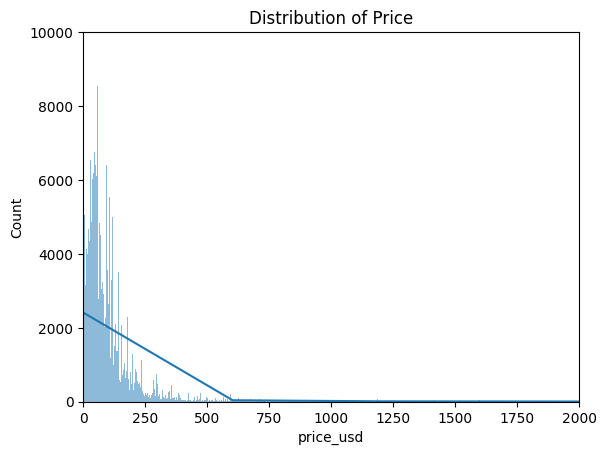

In [13]:
sns.histplot(data = nume, x = 'price_usd',kde = True)
plt.title('Distribution of Price')
plt.ylim(0, 10000)
plt.xlim(0, 2000)
plt.show()

In [14]:
cols = ['host_response_rate', 'host_acceptance_rate',
       'host_total_listings_count', 'latitude', 'longitude', 'accommodates',
       'bedrooms', 'minimum_nights', 'maximum_nights',
       'review_scores_rating', 'review_scores_accuracy',
       'review_scores_cleanliness', 'review_scores_checkin',
       'review_scores_communication', 'review_scores_location',
       'review_scores_value']
nume[cols].describe()

,host_response_rate,host_acceptance_rate,host_total_listings_count,latitude,longitude,accommodates,bedrooms,minimum_nights,maximum_nights,review_scores_rating,review_scores_accuracy,review_scores_cleanliness,review_scores_checkin,review_scores_communication,review_scores_location,review_scores_value
count,150930.000000,166625.000000,279547.000000,279712.000000,279712.000000,279712.000000,250277.000000,279712.000000,2.797120e+05,188307.000000,187999.000000,188047.000000,187941.000000,188025.000000,187937.000000,187927.000000
mean,0.865939,0.827168,24.581612,18.761862,12.595075,3.288736,1.515509,8.050967,2.755860e+04,93.405195,9.565476,9.312869,9.701534,9.698593,9.633994,9.335364
std,0.283744,0.289202,284.041143,32.560343,73.081309,2.133379,1.153080,31.518946,7.282875e+06,10.070437,0.990878,1.146072,0.867434,0.886884,0.833234,1.042625
min,0.000000,0.000000,0.000000,-34.264400,-99.339630,0.000000,1.000000,1.000000,1.000000e+00,20.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000
25%,0.900000,0.780000,1.000000,-22.964390,-43.198040,2.000000,1.000000,1.000000,4.500000e+01,91.000000,9.000000,9.000000,10.000000,10.000000,9.000000,9.000000
50%,1.000000,0.980000,1.000000,40.710785,2.382780,2.000000,1.000000,2.000000,1.125000e+03,96.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000
75%,1.000000,1.000000,4.000000,41.908610,28.986730,4.000000,2.000000,5.000000,1.125000e+03,100.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000
max,1.000000,1.000000,7235.000000,48.904910,151.339810,16.000000,50.000000,9999.000000,2.147484e+09,100.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000



Most hosts show high response and acceptance rates, listings are geographically diverse, properties typically accommodate 2–4 guests with 1–2 bedrooms, review scores are strongly concentrated near 9–10, and several features (host listings count, max nights, bedrooms) exhibit heavy right-skew with extreme outliers; 


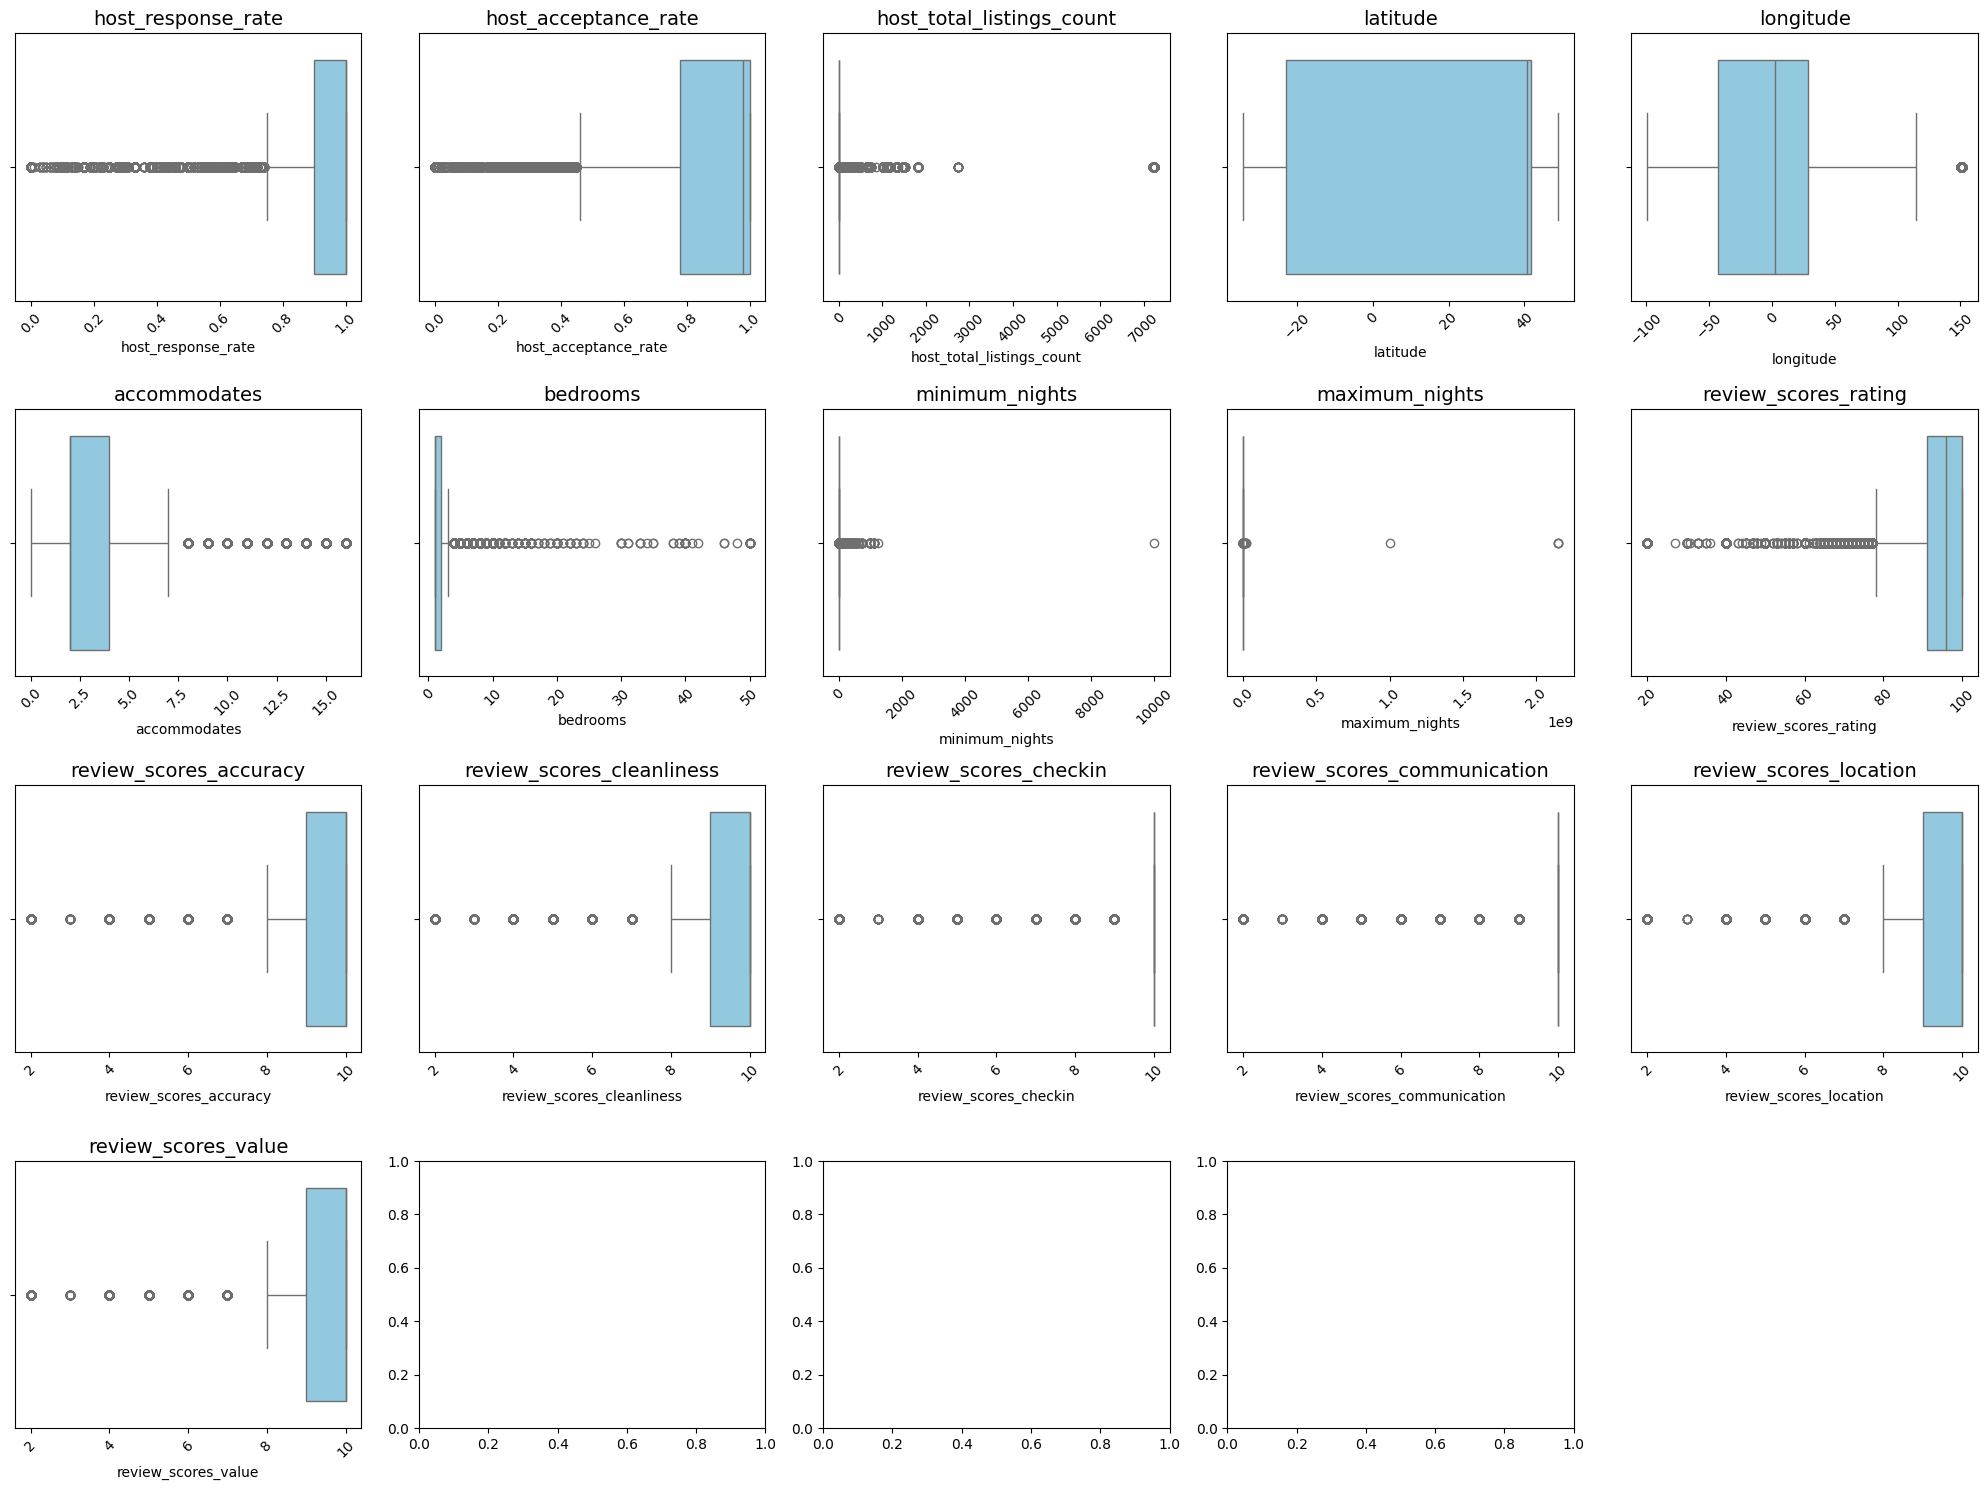

In [15]:
nume_u = nume[cols]
fig, axs = plt.subplots(4, 5, figsize=(20, 15))  
axs = axs.flatten()  
for i, col in enumerate(nume_u):
    sns.boxplot(data=nume, x=col, ax=axs[i], color='skyblue')
    axs[i].set_title(col, fontsize=14)
    axs[i].tick_params(axis='x', rotation=45)
fig.delaxes(axs[-1])
plt.tight_layout()
plt.show()

Several variables (host_total_listings_count, bedrooms, minimum_nights, maximum_nights, price) show strong right-skew and extreme outliers.


In [16]:
cate.columns

Index(['name', 'host_since', 'host_location', 'host_response_time',
       'host_is_superhost', 'host_has_profile_pic', 'host_identity_verified',
       'neighbourhood', 'district', 'city', 'property_type', 'room_type',
       'amenities', 'instant_bookable', 'country_clean'],
      dtype='object')

C:\Users\hp\AppData\Local\Temp\ipykernel_5100\652309247.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=cate, x=col, order=cate[col].value_counts().index,
C:\Users\hp\AppData\Local\Temp\ipykernel_5100\652309247.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=cate, x=col, order=cate[col].value_counts().index,


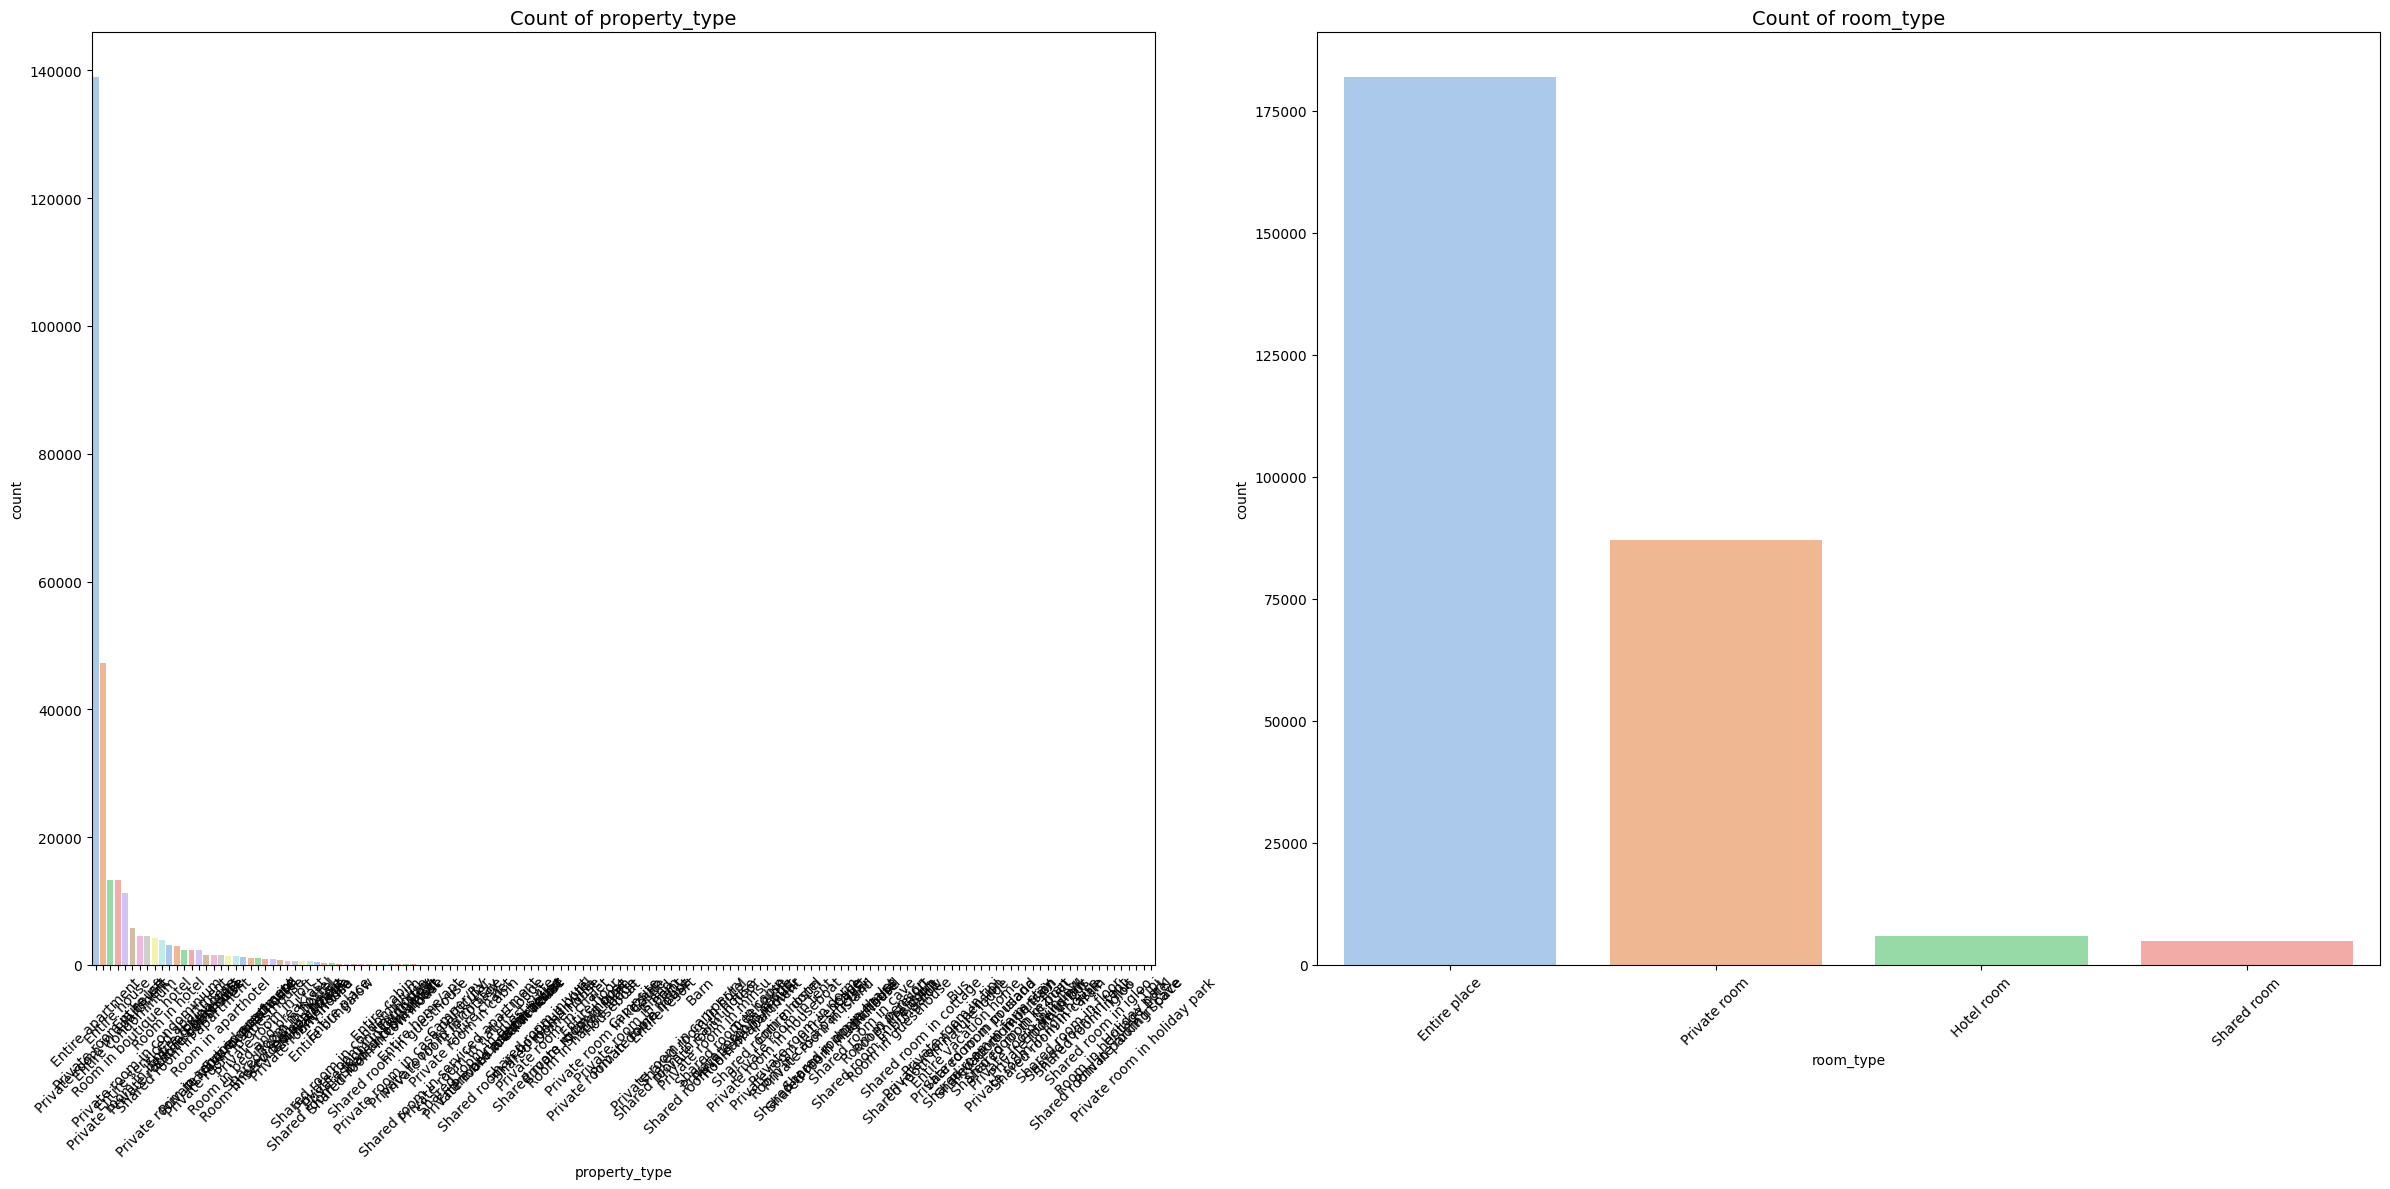

In [17]:
cat_u = ['property_type', 'room_type',]

fig, axs = plt.subplots(1, 2, figsize=(24, 12))  
axs = axs.flatten()

for i, col in enumerate(cat_u):
    sns.countplot(data=cate, x=col, order=cate[col].value_counts().index,
                  ax=axs[i], palette='pastel')
    axs[i].set_title(f'Count of {col}', fontsize=14)
    axs[i].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

plt.show()

## Bivariate Analysis

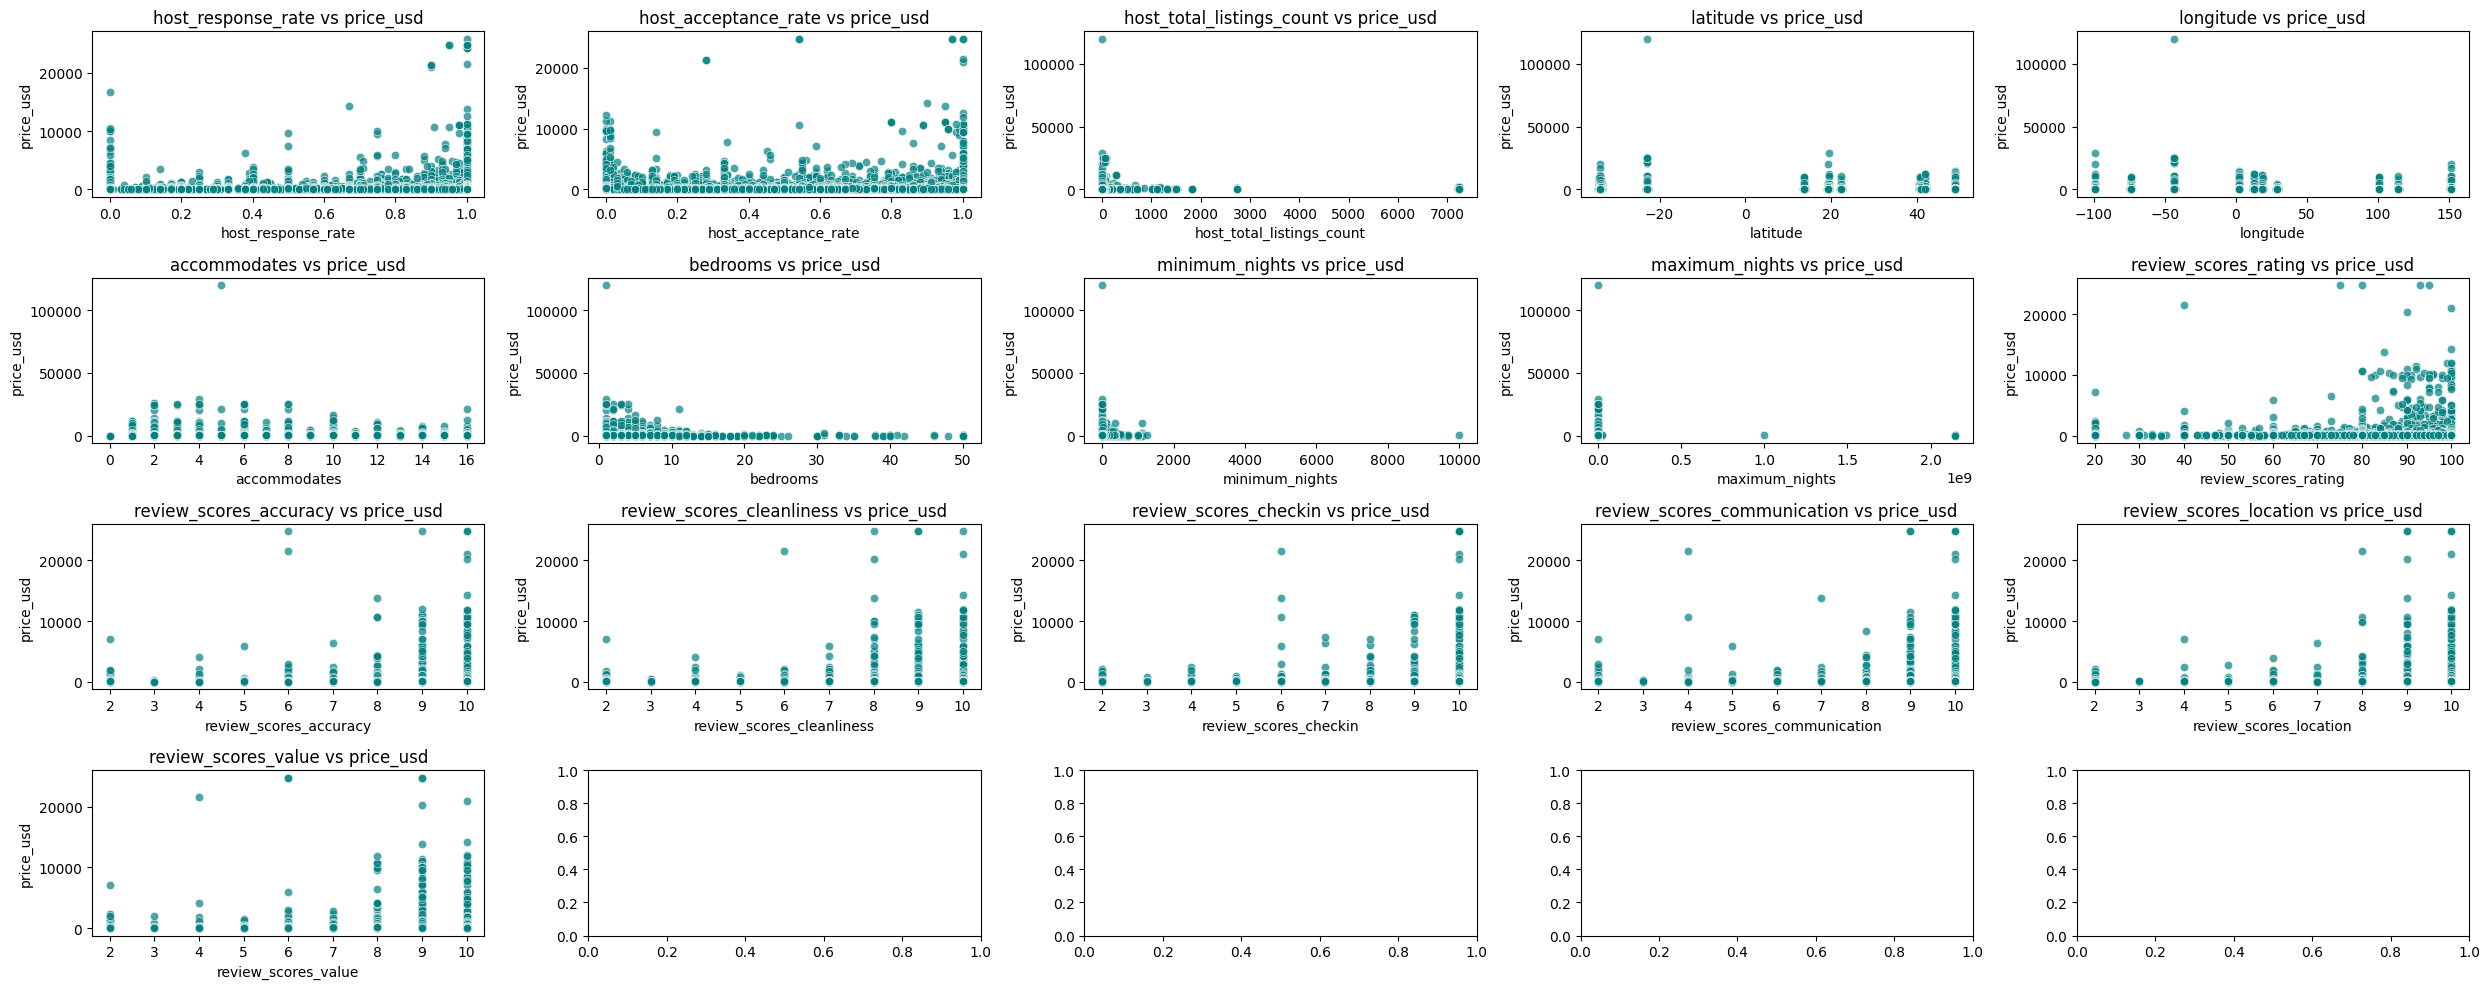

In [18]:
fig, axs = plt.subplots(4, 5, figsize=(25, 10))  
axs = axs.flatten()

for i, col in enumerate(nume_u):
    sns.scatterplot(x=d1[col], y=d1['price_usd'], ax=axs[i], color='teal', alpha=0.7)
    axs[i].set_title(f'{col} vs price_usd', fontsize=12)
    axs[i].set_xlabel(col, fontsize=10)
    axs[i].set_ylabel('price_usd', fontsize=10)

plt.tight_layout()
plt.show()


Price increases moderately with accommodates and bedrooms, while most other features show weak or scattered relationships.
Higher review scores slightly align with higher prices, but relationship is weak and dispersed.


C:\Users\hp\AppData\Local\Temp\ipykernel_5100\231194742.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=col, y='price_usd', data=d1, ax=axs[i], palette='pastel')
C:\Users\hp\AppData\Local\Temp\ipykernel_5100\231194742.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=col, y='price_usd', data=d1, ax=axs[i], palette='pastel')


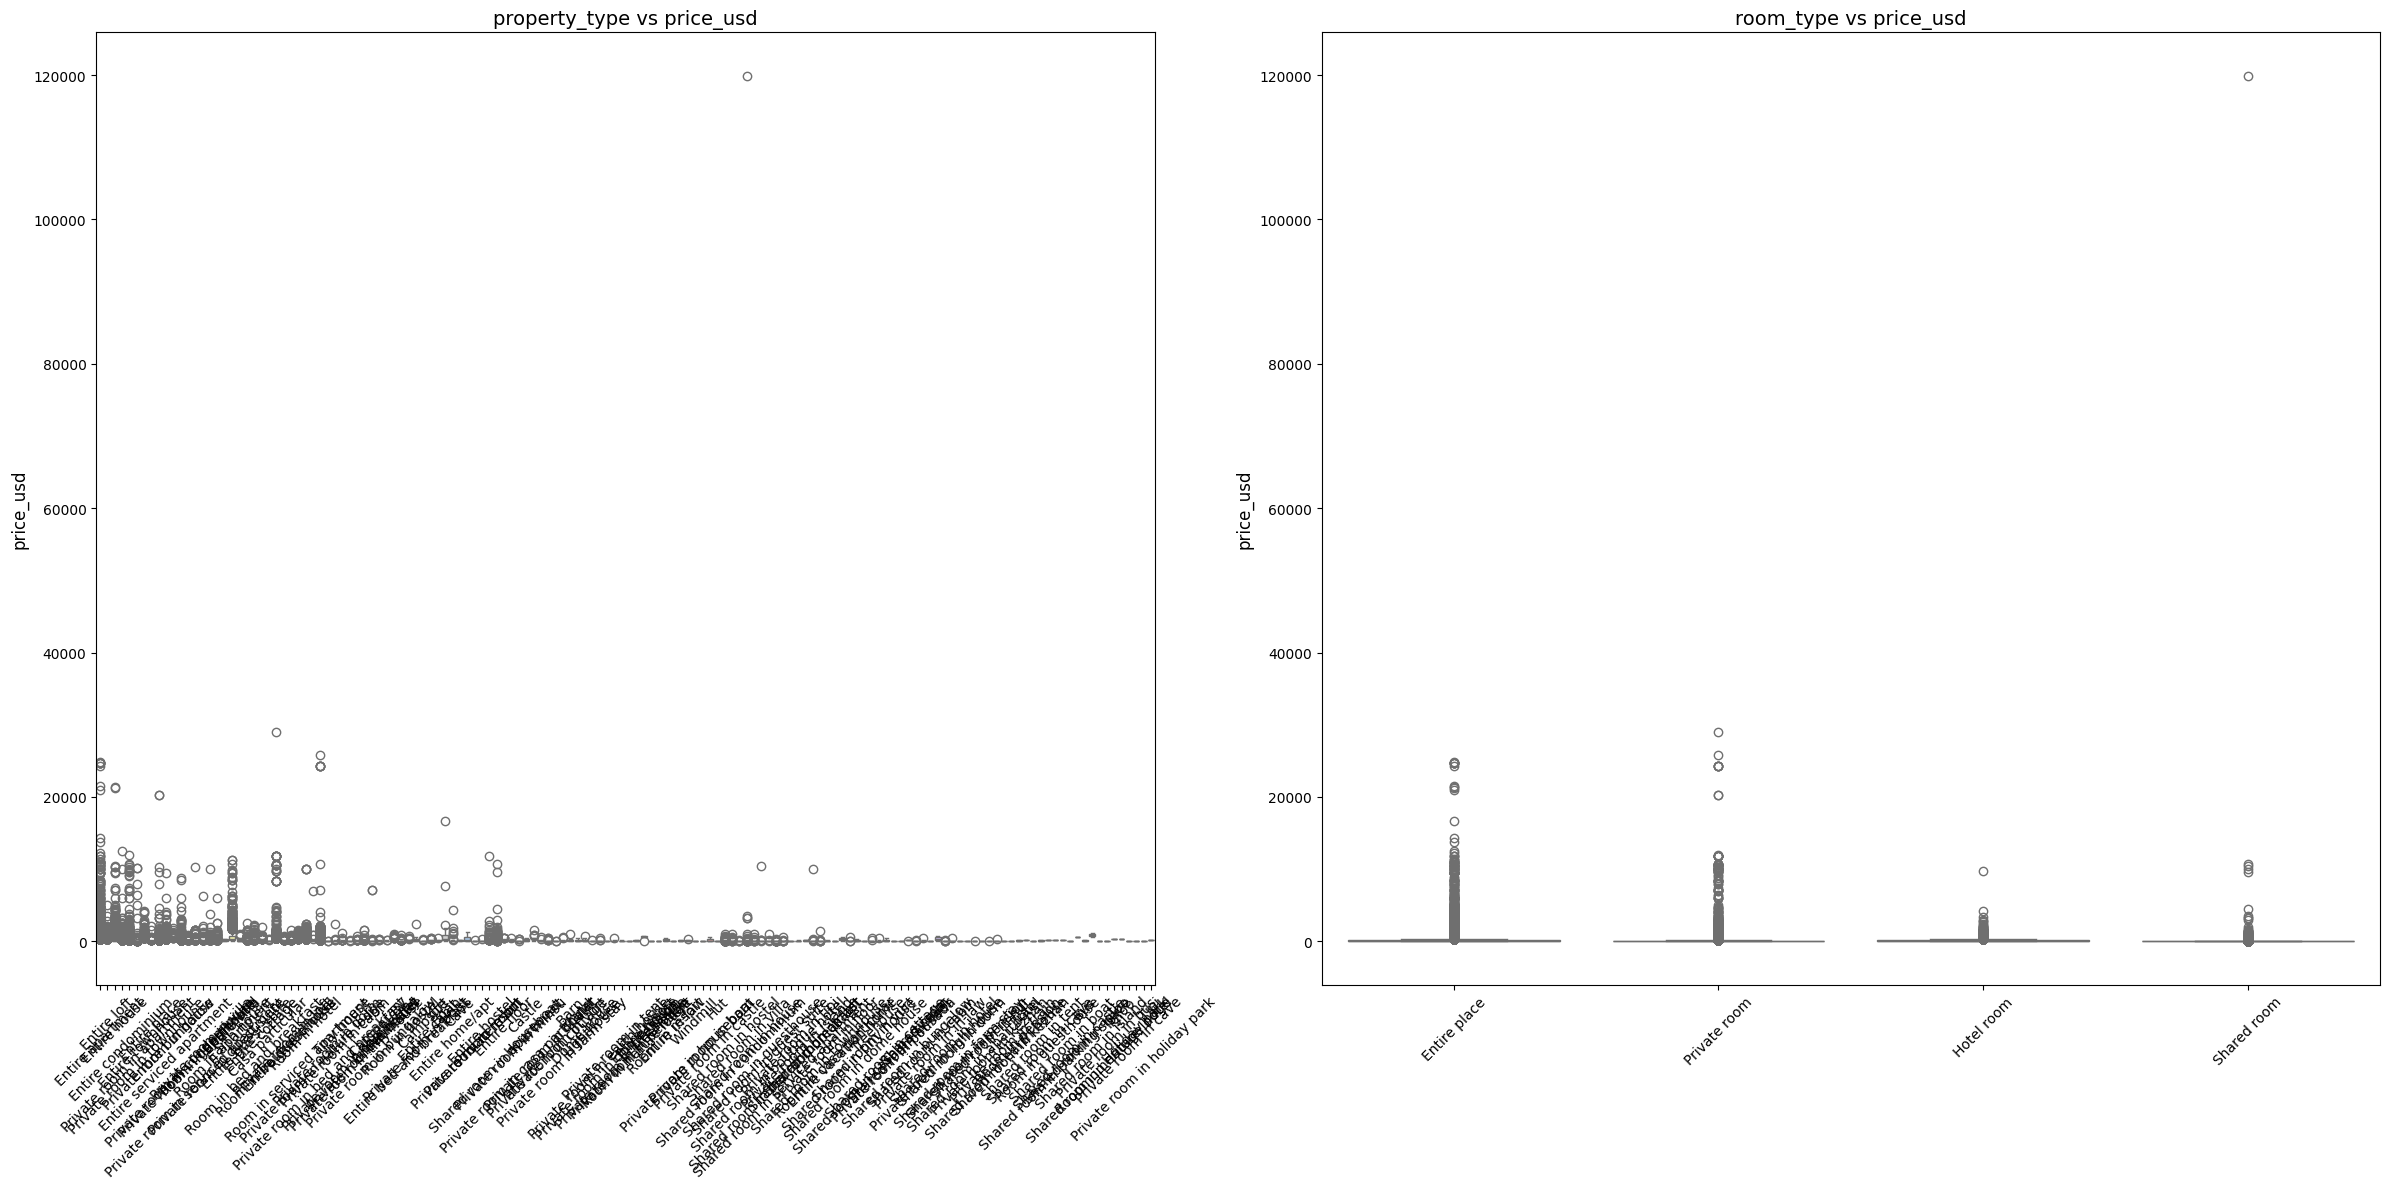

In [19]:
fig, axs = plt.subplots(1, 2, figsize=(24, 12))  
axs = axs.flatten()

for i, col in enumerate(cat_u):
    sns.boxplot(x=col, y='price_usd', data=d1, ax=axs[i], palette='pastel')
    axs[i].set_title(f'{col} vs price_usd', fontsize=14)
    axs[i].tick_params(axis='x', rotation=45)
    axs[i].set_xlabel('')
    axs[i].set_ylabel('price_usd', fontsize=12)

plt.tight_layout()
plt.show()


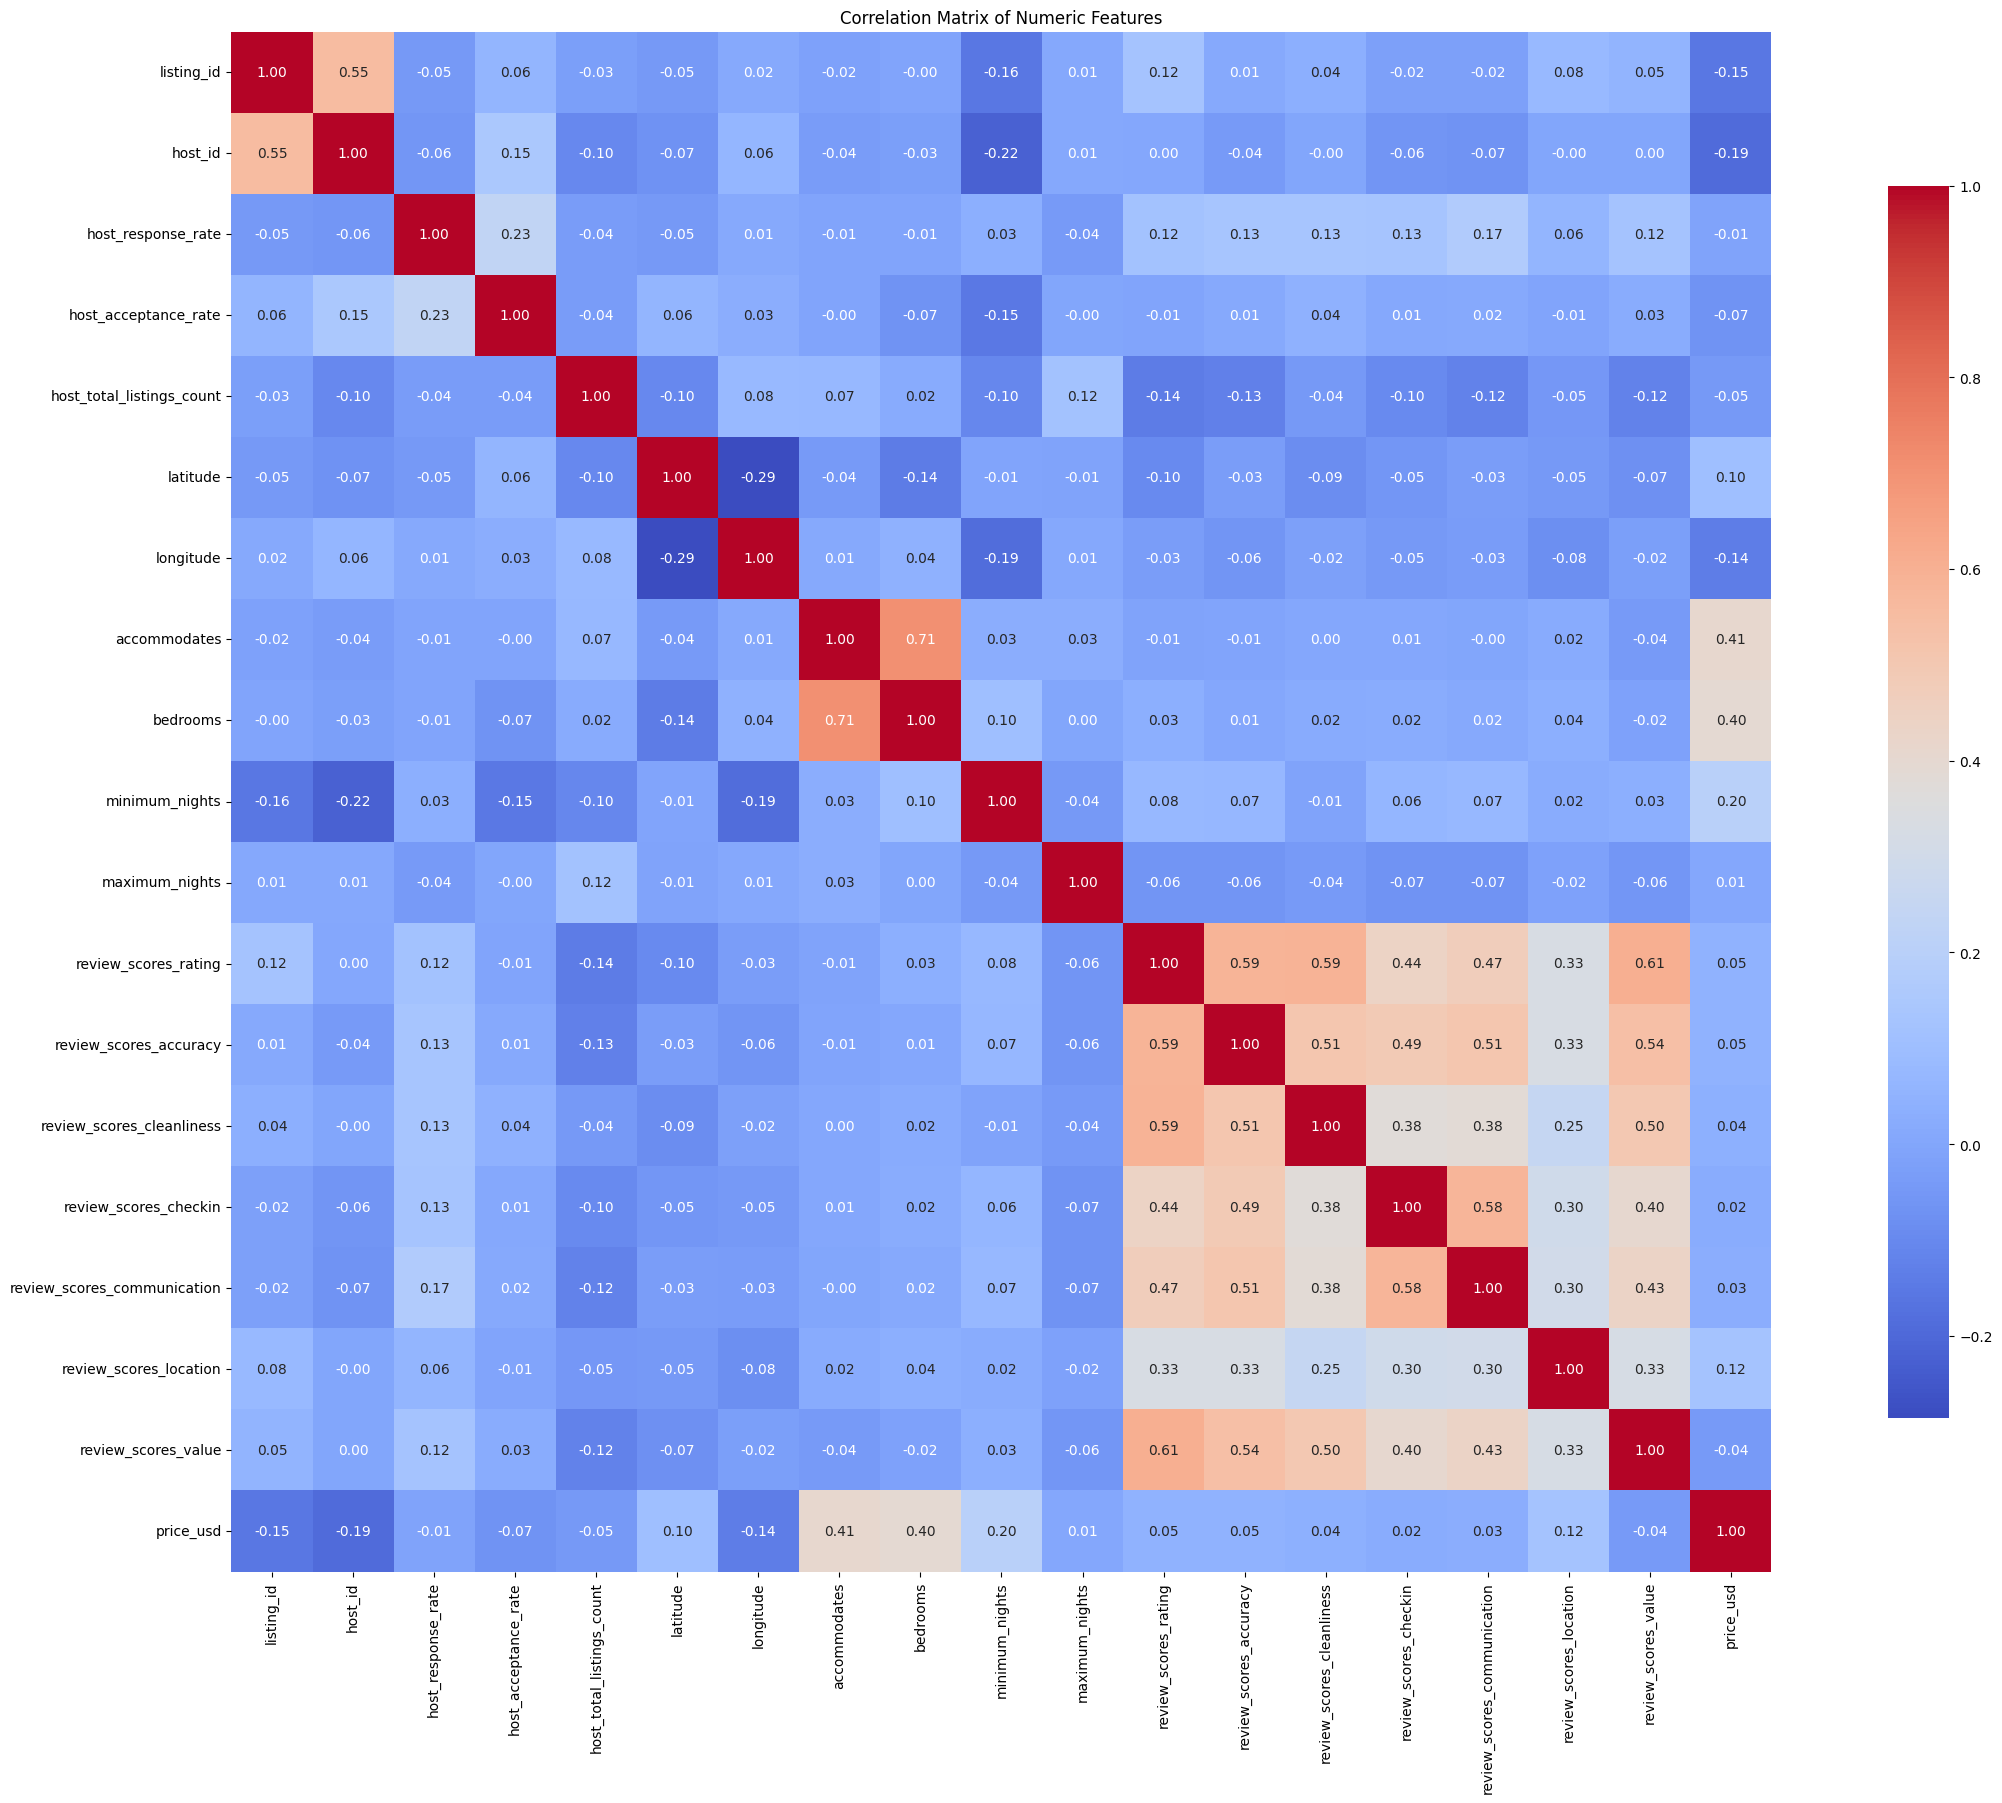

In [20]:
nume_col = d1.select_dtypes(include=['number']).columns.drop(['price','usd_rate'])
corr_matrix = d1[nume_col].corr(method='spearman')

plt.figure(figsize=(30,20))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", square=True, cbar_kws={"shrink": .8})
plt.title("Correlation Matrix of Numeric Features")
plt.show()

Accommodates (0.41) and bedrooms (0.40) show strongest positive correlation with price; most other variables have weak linear correlation.


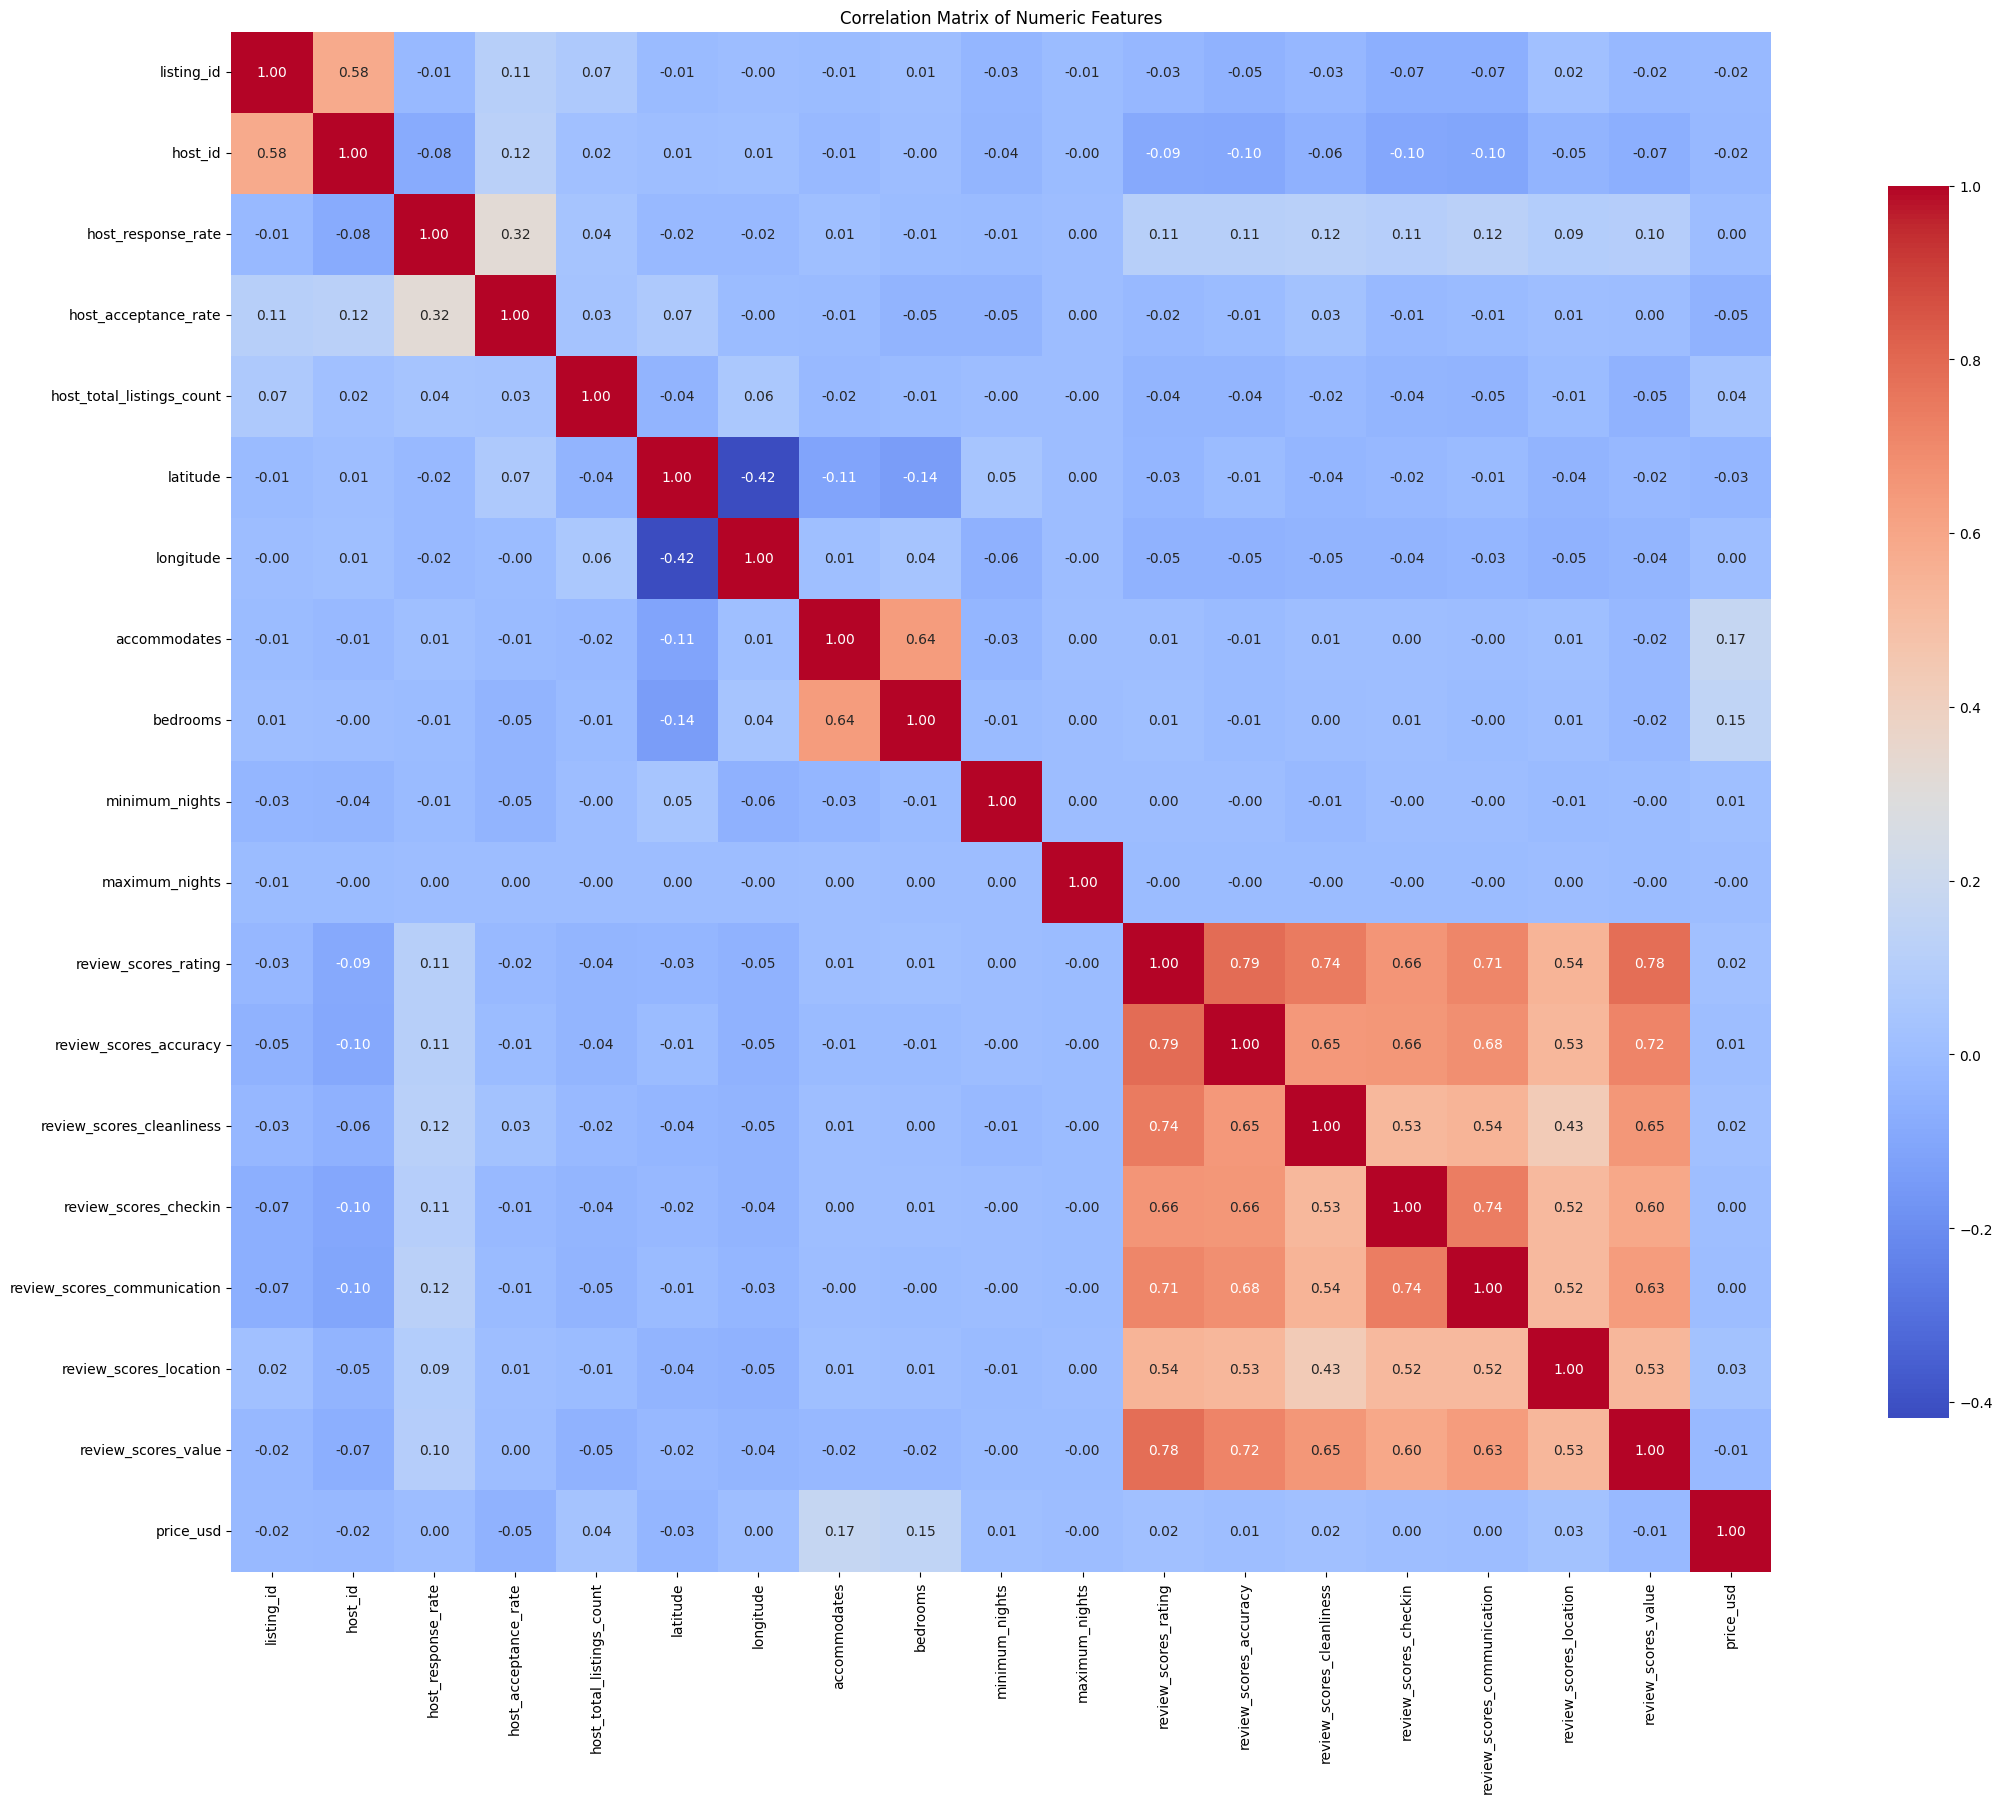

In [21]:
nume_col = d1.select_dtypes(include=['number']).columns.drop(['price','usd_rate'])
corr_matrix = d1[nume_col].corr()

plt.figure(figsize=(30,20))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", square=True, cbar_kws={"shrink": .8})
plt.title("Correlation Matrix of Numeric Features")
plt.show()

# Data Preprocessing

In [22]:
d1.isnull().sum()

listing_id                          0
name                              175
host_id                             0
host_since                        165
host_location                     840
host_response_time             128782
host_response_rate             128782
host_acceptance_rate           113087
host_is_superhost                 165
host_total_listings_count         165
host_has_profile_pic              165
host_identity_verified            165
neighbourhood                       0
district                       242700
city                                0
latitude                            0
longitude                           0
property_type                       0
room_type                           0
accommodates                        0
bedrooms                        29435
amenities                           0
price                               0
minimum_nights                      0
maximum_nights                      0
review_scores_rating            91405
review_score

In [23]:
(d1.isna().mean() * 100).sort_values(ascending=False)


district                       86.767818
host_response_time             46.040928
host_response_rate             46.040928
host_acceptance_rate           40.429799
review_scores_value            32.814109
review_scores_location         32.810534
review_scores_checkin          32.809104
review_scores_accuracy         32.788368
review_scores_communication    32.779073
review_scores_cleanliness      32.771208
review_scores_rating           32.678255
bedrooms                       10.523324
host_location                   0.300309
name                            0.062564
host_since                      0.058989
host_is_superhost               0.058989
host_identity_verified          0.058989
host_total_listings_count       0.058989
host_has_profile_pic            0.058989
listing_id                      0.000000
host_id                         0.000000
accommodates                    0.000000
property_type                   0.000000
room_type                       0.000000
latitude        

In [24]:
d1.drop(columns=['district','host_response_time','host_response_rate','host_acceptance_rate','usd_rate','country_clean'], inplace=True)

dropped columns which had more than 40% null values

In [25]:
d1.drop(columns=['host_location','host_has_profile_pic','latitude','longitude','price','listing_id','host_id','host_is_superhost','name'],inplace=True)

dropped columns which give no predictive values and other redundent or less impactfull columns

In [26]:
d1[['review_scores_rating', 'review_scores_accuracy', 'review_scores_cleanliness','review_scores_checkin', 'review_scores_communication','review_scores_location', 'review_scores_value']] = d1[['review_scores_rating', 'review_scores_accuracy', 'review_scores_cleanliness',
       'review_scores_checkin', 'review_scores_communication','review_scores_location', 'review_scores_value']].fillna(d1[['review_scores_rating', 'review_scores_accuracy', 'review_scores_cleanliness','review_scores_checkin', 'review_scores_communication','review_scores_location', 'review_scores_value']].mean())

filled the important coumns which had less than 40% null values using mean

In [27]:
d1.dropna(inplace=True)

In [28]:
d1.duplicated().sum()

np.int64(1483)

In [29]:
n = d1.select_dtypes(include=['int', 'float']).columns

zero_percent = (d1[n] == 0).sum() / len(d1) * 100
print(zero_percent.sort_values(ascending=False))


host_total_listings_count      11.83775
accommodates                    0.00000
bedrooms                        0.00000
minimum_nights                  0.00000
maximum_nights                  0.00000
review_scores_rating            0.00000
review_scores_accuracy          0.00000
review_scores_cleanliness       0.00000
review_scores_checkin           0.00000
review_scores_communication     0.00000
review_scores_location          0.00000
review_scores_value             0.00000
price_usd                       0.00000
dtype: float64


In [30]:
outlier_features = [
    "maximum_nights",
    "minimum_nights",
    "host_total_listings_count",
    "bedrooms"
]

def clean_outliers(df, cols):
    for col in cols:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR
        
        df[col] = df[col].clip(lower, upper)
            
    return df

d1 = clean_outliers(d1, outlier_features)


capped the extream outliers than removing them

In [31]:
d1.dtypes

host_since                      object
host_total_listings_count      float64
host_identity_verified          object
neighbourhood                   object
city                            object
property_type                   object
room_type                       object
accommodates                     int64
bedrooms                       float64
amenities                       object
minimum_nights                   int64
maximum_nights                   int64
review_scores_rating           float64
review_scores_accuracy         float64
review_scores_cleanliness      float64
review_scores_checkin          float64
review_scores_communication    float64
review_scores_location         float64
review_scores_value            float64
instant_bookable                object
price_usd                      float64
dtype: object

In [32]:
d1['host_since'] = pd.to_datetime(d1['host_since'], errors='coerce')
bool_cols = [
    'host_identity_verified',
    'instant_bookable'
]

for col in bool_cols:
    d1[col] = d1[col].map({'t': 1, 'f': 0}).astype('float64')


# Feature Engineering

In [33]:
d1.dtypes

host_since                     datetime64[ns]
host_total_listings_count             float64
host_identity_verified                float64
neighbourhood                          object
city                                   object
property_type                          object
room_type                              object
accommodates                            int64
bedrooms                              float64
amenities                              object
minimum_nights                          int64
maximum_nights                          int64
review_scores_rating                  float64
review_scores_accuracy                float64
review_scores_cleanliness             float64
review_scores_checkin                 float64
review_scores_communication           float64
review_scores_location                float64
review_scores_value                   float64
instant_bookable                      float64
price_usd                             float64
dtype: object

In [34]:
cate = d1.select_dtypes(include=['object'])
nume = d1.select_dtypes(include=['float64','int64'])

In [35]:
cate.columns, nume.columns

(Index(['neighbourhood', 'city', 'property_type', 'room_type', 'amenities'], dtype='object'),
 Index(['host_total_listings_count', 'host_identity_verified', 'accommodates',
        'bedrooms', 'minimum_nights', 'maximum_nights', 'review_scores_rating',
        'review_scores_accuracy', 'review_scores_cleanliness',
        'review_scores_checkin', 'review_scores_communication',
        'review_scores_location', 'review_scores_value', 'instant_bookable',
        'price_usd'],
       dtype='object'))

In [36]:
nume.skew().sort_values(ascending=False)

price_usd                      101.328887
accommodates                     2.070460
bedrooms                         1.451879
minimum_nights                   1.246861
host_total_listings_count        1.113741
instant_bookable                 0.351861
maximum_nights                  -0.358494
host_identity_verified          -0.980537
review_scores_cleanliness       -3.735913
review_scores_value             -4.011754
review_scores_rating            -4.649009
review_scores_accuracy          -5.180289
review_scores_location          -5.243658
review_scores_communication     -6.445540
review_scores_checkin           -6.496097
dtype: float64

In [37]:
d1['price_usd'] = np.log1p(d1['price_usd'])
d1['host_total_listings_count'] = np.log1p(d1['host_total_listings_count'])


price was extremely right-skewed (skew = 101), indicating heavy outliers. log1p transformation was applied to reduce skewness and stabilize variance, improving suitability for modeling.


In [38]:
d1['room_type'].unique(), d1['property_type'].nunique(), d1['neighbourhood'].nunique(), d1['city'].nunique()

(array(['Entire place', 'Private room', 'Hotel room', 'Shared room'],
       dtype=object),
 142,
 659,
 10)

In [39]:
neigh_freq = d1['neighbourhood'].value_counts(normalize=True)
d1['neighbourhood_freq'] = d1['neighbourhood'].map(neigh_freq)

prop_freq = d1['property_type'].value_counts(normalize=True)
d1['property_type_freq'] = d1['property_type'].map(prop_freq)

d1.drop(columns=['neighbourhood', 'property_type'], inplace=True)


applied frequency encoding to convert high-cardinality categorical features into numerical form based on relative occurrence, then dropped original columns to reduce dimensionality and avoid sparse one-hot encoding.


In [40]:
d1 = pd.get_dummies(d1,columns=['city', 'room_type'], drop_first=True, dtype='int')

one hot encoded city and room_type (nominal column)

In [41]:
d1['amenities'].head(1)

0    ["Heating", "Kitchen", "Washer", "Wifi", "Long...
Name: amenities, dtype: object

In [ ]:
from sklearn.preprocessing import MultiLabelBinarizer
import ast

d1['amenities'] = d1['amenities'].apply(lambda x: ast.literal_eval(x) if isinstance(x, str) else x)

mlb = MultiLabelBinarizer()
amenities_encoded = mlb.fit_transform(d1['amenities'])
amenities_df = pd.DataFrame(amenities_encoded, columns=mlb.classes_, index=d1.index)
#  dropping amenities that appear in fewer than min_count listings
min_count = 1000
amenities_df = amenities_df.loc[:, amenities_df.sum() >= min_count]
d1 = pd.concat([d1.drop(columns=['amenities']), amenities_df], axis=1)


In [43]:
d1.shape

(250132, 134)

In [44]:
d1.head()

,host_since,host_total_listings_count,host_identity_verified,accommodates,bedrooms,minimum_nights,maximum_nights,review_scores_rating,review_scores_accuracy,review_scores_cleanliness,...,Sound system,Stove,TV,Table corner guards,Toaster,Washer,Waterfront,Wifi,Window guards,Wine glasses
0,2011-12-03,0.693147,0.0,2,1.0,2,1125,100.0,10.0,10.0,...,0,0,0,0,0,1,0,1,0,0
1,2013-11-29,0.693147,1.0,2,1.0,2,1125,100.0,10.0,10.0,...,0,0,0,0,0,1,0,1,0,0
2,2014-07-31,0.693147,0.0,2,1.0,2,1125,100.0,10.0,10.0,...,0,0,1,0,0,1,0,1,0,0
3,2013-12-17,0.693147,1.0,2,1.0,2,1125,100.0,10.0,10.0,...,0,0,1,0,0,0,0,1,0,0
4,2014-12-14,0.693147,0.0,2,1.0,2,1125,100.0,10.0,10.0,...,0,0,1,0,0,1,0,1,0,0


In [45]:
d1['host_since'] = pd.to_datetime(d1['host_since'], errors='coerce')
d1['host_since_year'] = d1['host_since'].dt.year
d1.drop(columns=['host_since'], inplace=True)


extracted year data from host_since and remove the column

In [46]:
d1.columns[:16]

Index(['host_total_listings_count', 'host_identity_verified', 'accommodates',
       'bedrooms', 'minimum_nights', 'maximum_nights', 'review_scores_rating',
       'review_scores_accuracy', 'review_scores_cleanliness',
       'review_scores_checkin', 'review_scores_communication',
       'review_scores_location', 'review_scores_value', 'instant_bookable',
       'price_usd', 'neighbourhood_freq'],
      dtype='object')

In [47]:
d1[['host_total_listings_count', 'host_identity_verified', 'accommodates',
       'bedrooms', 'minimum_nights', 'maximum_nights', 'review_scores_rating',
       'review_scores_accuracy', 'review_scores_cleanliness',
       'review_scores_checkin', 'review_scores_communication',
       'review_scores_location', 'review_scores_value', 'instant_bookable',
       'price_usd']].describe()

,host_total_listings_count,host_identity_verified,accommodates,bedrooms,minimum_nights,maximum_nights,review_scores_rating,review_scores_accuracy,review_scores_cleanliness,review_scores_checkin,review_scores_communication,review_scores_location,review_scores_value,instant_bookable,price_usd
count,250132.000000,250132.000000,250132.000000,250132.000000,250132.000000,250132.000000,250132.000000,250132.000000,250132.000000,250132.000000,250132.000000,250132.000000,250132.000000,250132.000000,250132.000000
mean,1.082562,0.720104,3.400708,1.455250,3.764516,688.798426,93.520972,9.570856,9.325841,9.706480,9.702810,9.634609,9.347388,0.413366,4.186162
std,0.698303,0.448949,2.192104,0.740895,3.504224,515.005321,8.170555,0.807031,0.928780,0.704799,0.720529,0.679865,0.846121,0.492438,1.090018
min,0.000000,0.000000,1.000000,1.000000,1.000000,1.000000,20.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,0.000000,0.120387
25%,0.693147,0.000000,2.000000,1.000000,1.000000,43.000000,93.405195,9.565476,9.000000,9.701534,9.698593,9.633994,9.000000,0.000000,3.614956
50%,0.693147,1.000000,3.000000,1.000000,2.000000,1125.000000,93.405195,9.565476,9.312869,10.000000,10.000000,10.000000,9.335364,0.000000,4.279670
75%,1.609438,1.000000,4.000000,2.000000,5.000000,1125.000000,98.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,1.000000,4.828658
max,2.251292,1.000000,16.000000,3.500000,11.000000,2748.000000,100.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,1.000000,11.694686


In [48]:
from sklearn.preprocessing import StandardScaler

d1['maximum_nights_log'] = np.log1p(d1['maximum_nights'])
num_cols = [
    'host_total_listings_count', 'accommodates', 'bedrooms',
    'minimum_nights', 'maximum_nights_log', 
    'price_usd',
    'review_scores_rating', 'review_scores_accuracy',
    'review_scores_cleanliness', 'review_scores_checkin',
    'review_scores_communication', 'review_scores_location', 'review_scores_value'
]

scaler = StandardScaler()
d1[num_cols] = scaler.fit_transform(d1[num_cols])
d1[num_cols] = d1[num_cols].round(3)



Used standardScaler to scale the extream numerical values to a common scale, used StandardScaler because the data was clear of outliers

In [49]:
d1[num_cols].describe()

,host_total_listings_count,accommodates,bedrooms,minimum_nights,maximum_nights_log,price_usd,review_scores_rating,review_scores_accuracy,review_scores_cleanliness,review_scores_checkin,review_scores_communication,review_scores_location,review_scores_value
count,250132.000000,250132.000000,250132.000000,250132.000000,250132.000000,250132.000000,250132.000000,250132.000000,250132.000000,250132.000000,250132.000000,250132.000000,250132.000000
mean,-0.000027,-0.000061,0.000267,-0.000079,0.000125,-0.000010,0.000046,0.000065,-0.000015,-0.000208,-0.000263,-0.000191,-0.000115
std,1.000134,0.999997,0.999791,1.000124,1.000140,1.000007,1.000014,1.000020,1.000108,0.999845,0.999869,0.999811,0.999920
min,-1.550000,-1.095000,-0.614000,-0.789000,-2.776000,-3.730000,-8.998000,-9.381000,-7.888000,-10.934000,-10.691000,-11.230000,-8.684000
25%,-0.558000,-0.639000,-0.614000,-0.789000,-1.049000,-0.524000,-0.014000,-0.007000,-0.351000,-0.007000,-0.006000,-0.001000,-0.411000
50%,-0.558000,-0.183000,-0.614000,-0.504000,0.763000,0.086000,-0.014000,-0.007000,-0.014000,0.416000,0.412000,0.537000,-0.014000
75%,0.755000,0.273000,0.735000,0.353000,0.763000,0.589000,0.548000,0.532000,0.726000,0.416000,0.412000,0.537000,0.771000
max,1.674000,5.748000,2.760000,2.065000,1.262000,6.888000,0.793000,0.532000,0.726000,0.416000,0.412000,0.537000,0.771000


In [51]:
import pandas as pd
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score

# Separate features and target
X = d1.drop(columns=['price_usd'])
y = d1['price_usd']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Initialize Random Forest
rf = RandomForestRegressor(
    n_estimators=200,
    max_depth=None,
    random_state=42,
    n_jobs=-1
)

# Train
rf.fit(X_train, y_train)

# Evaluate
y_pred = rf.predict(X_test)
print("R2 Score:", r2_score(y_test, y_pred))

# Feature Importance
importances = pd.Series(
    rf.feature_importances_,
    index=X_train.columns
).sort_values(ascending=False)

print("\nTop 20 Important Features:")
print(importances.head(20))


R2 Score: 0.7884978927293039

Top 20 Important Features:
city_Istanbul                0.383608
bedrooms                     0.138449
Heating                      0.057575
neighbourhood_freq           0.037480
room_type_Private room       0.029554
accommodates                 0.029250
host_since_year              0.017898
property_type_freq           0.016745
host_total_listings_count    0.016684
minimum_nights               0.012918
city_Paris                   0.012419
city_New York                0.011135
review_scores_rating         0.008632
Air conditioning             0.007767
city_Sydney                  0.007539
Dryer                        0.007190
maximum_nights_log           0.006865
maximum_nights               0.006830
room_type_Shared room        0.005949
city_Mexico City             0.005838
dtype: float64


extracted and reviewd top 20 important features through feature importance with Random forest

In [52]:
d1.groupby('city_Istanbul')['price_usd'].mean()


city_Istanbul
0    0.194310
1   -1.968734
Name: price_usd, dtype: float64

In [ ]:
# Setting threshold for feature importance
threshold = 0.0005
selected_features = importances[importances >= threshold].index.tolist()
d1_filtered_rf = d1[selected_features + ['price_usd']]  
print("Filtered dataframe shape:", d1_filtered_rf.shape)
print(d1_filtered_rf.head())


Filtered dataframe shape: (250132, 95)
   city_Istanbul  bedrooms  Heating  neighbourhood_freq  \
0              0    -0.614        1            0.023472   
1              0    -0.614        1            0.023472   
2              0    -0.614        1            0.005713   
3              0    -0.614        1            0.014892   
4              0    -0.614        1            0.009795   

   room_type_Private room  accommodates  host_since_year  property_type_freq  \
0                       0        -0.639             2011            0.473298   
1                       0        -0.639             2013            0.473298   
2                       0        -0.639             2014            0.473298   
3                       0        -0.639             2013            0.473298   
4                       0        -0.639             2014            0.473298   

   host_total_listings_count  minimum_nights  ...  Cleaning before checkout  \
0                     -0.558          -0.504  

 threshold = 0.0005 which gave 95 columns proved to be the best one

In [54]:
import pandas as pd
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score

# Separate features and target
X = d1_filtered_rf.drop(columns=['price_usd'])
y = d1_filtered_rf['price_usd']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Initialize Random Forest
rf = RandomForestRegressor(
    n_estimators=200,
    max_depth=None,
    random_state=42,
    n_jobs=-1
)

# Train
rf.fit(X_train, y_train)

# Evaluate
y_pred = rf.predict(X_test)
print("R2 Score:", r2_score(y_test, y_pred))  #0.0005 - 0.7886, 0.0008 - 0.7885, 0.0002 - 0.7884


R2 Score: 0.7886279720411615


# MLP MODEL

In [64]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, random_split
from sklearn.metrics import r2_score

device = 'cuda' if torch.cuda.is_available() else 'cpu'

class MyDataset(Dataset):
    def __init__(self, dataframe):
        self.X = torch.tensor(
            dataframe.drop('price_usd', axis=1).values,
            dtype=torch.float32
        )
        self.y = torch.tensor(
            dataframe['price_usd'].values,
            dtype=torch.float32
        ).unsqueeze(1)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]


dataset = MyDataset(d1_filtered_rf)

train_size = int(0.8 * len(dataset))
val_size = len(dataset) - train_size

train_dataset, val_dataset = random_split(dataset, [train_size, val_size])

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)

input_dim = d1_filtered_rf.shape[1] - 1

class MLP(nn.Module):
    def __init__(self, input_dim):
        super().__init__()

        self.L1 = nn.Linear(input_dim, 256)
        self.L2 = nn.Linear(256, 128)
        self.L3 = nn.Linear(128, 64)
        self.L4 = nn.Linear(64, 32)
        self.out = nn.Linear(32, 1)

        self.act = nn.LeakyReLU(0.01)

    def forward(self, x):
        x = self.act(self.L1(x))
        x = self.act(self.L2(x))
        x = self.act(self.L3(x))
        x = self.act(self.L4(x))
        x = self.out(x)
        return x


model = MLP(input_dim).to(device)

criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.002)

epochs = 30

for epoch in range(epochs):

    model.train()
    train_loss = 0

    for x_batch, y_batch in train_loader:
        x_batch = x_batch.to(device)
        y_batch = y_batch.to(device)

        preds = model(x_batch)
        loss = criterion(preds, y_batch)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        train_loss += loss.item()

    train_loss /= len(train_loader)

    model.eval()
    val_loss = 0
    all_preds = []
    all_targets = []

    with torch.no_grad():
        for x_batch, y_batch in val_loader:
            x_batch = x_batch.to(device)
            y_batch = y_batch.to(device)

            preds = model(x_batch)
            loss = criterion(preds, y_batch)

            val_loss += loss.item()

            all_preds.append(preds.cpu())
            all_targets.append(y_batch.cpu())

    val_loss /= len(val_loader)

    all_preds = torch.cat(all_preds)
    all_targets = torch.cat(all_targets)

    r2 = r2_score(all_targets.numpy(), all_preds.numpy())

    print(f"Epoch {epoch+1:02d} | "
          f"Train Loss: {train_loss:.4f} | "
          f"Val Loss: {val_loss:.4f} | "
          f"Val R2: {r2:.4f}")


Epoch 01 | Train Loss: 0.4868 | Val Loss: 0.3260 | Val R2: 0.6764
Epoch 02 | Train Loss: 0.3310 | Val Loss: 0.3977 | Val R2: 0.6051
Epoch 03 | Train Loss: 0.3160 | Val Loss: 0.2982 | Val R2: 0.7040
Epoch 04 | Train Loss: 0.3138 | Val Loss: 0.3497 | Val R2: 0.6528
Epoch 05 | Train Loss: 0.3086 | Val Loss: 0.4078 | Val R2: 0.5952
Epoch 06 | Train Loss: 0.3081 | Val Loss: 0.3010 | Val R2: 0.7012
Epoch 07 | Train Loss: 0.3124 | Val Loss: 0.3047 | Val R2: 0.6975
Epoch 08 | Train Loss: 0.3088 | Val Loss: 0.2838 | Val R2: 0.7183
Epoch 09 | Train Loss: 0.3027 | Val Loss: 0.3019 | Val R2: 0.7003
Epoch 10 | Train Loss: 0.3054 | Val Loss: 0.3139 | Val R2: 0.6884
Epoch 11 | Train Loss: 1.0562 | Val Loss: 0.2814 | Val R2: 0.7206
Epoch 12 | Train Loss: 0.2919 | Val Loss: 0.2838 | Val R2: 0.7183
Epoch 13 | Train Loss: 0.3055 | Val Loss: 0.3902 | Val R2: 0.6125
Epoch 14 | Train Loss: 0.2994 | Val Loss: 0.2932 | Val R2: 0.7089
Epoch 15 | Train Loss: 0.2984 | Val Loss: 0.2841 | Val R2: 0.7180
Epoch 16 |

1) implemented traditional MLP neural network for precise price prediction using PyTorch
 2) deep feedforward architecture flows elegantly: input → 256 → 128 → 64 → 32 → price_usd
 3) powered by LeakyReLU(0.01) activations, Adam optimizer (lr=0.002), and MSE loss function
 4) trained 30 epochs on 80/20 split, achieving BEST performance at Epoch 30: Train 0.2972 | Val 0.2880 | R² 0.7141